In [15]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [16]:
pip install onnx onnxruntime torch torchvision

Note: you may need to restart the kernel to use updated packages.


In [17]:
# Using existing image
import cv2
print("Using existing image: Gambar Aktris.png")
img_check = cv2.imread("Gambar Aktris.png")
print(f"Image loaded: {img_check.shape if img_check is not None else 'NOT FOUND — check file location'}")

Using existing image: Gambar Aktris.png
Image loaded: (401, 382, 3)


In [18]:
import urllib.request
import os

# Download the model files
base_url = "https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel"
proto_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"

print("Downloading model files...")

if not os.path.exists("deploy.prototxt"):
    urllib.request.urlretrieve(proto_url, "deploy.prototxt")
    print("Downloaded deploy.prototxt")

if not os.path.exists("res10_300x300_ssd_iter_140000.caffemodel"):
    urllib.request.urlretrieve(base_url, "res10_300x300_ssd_iter_140000.caffemodel")
    print("Downloaded caffemodel")

print("Model files ready")

Model files ready


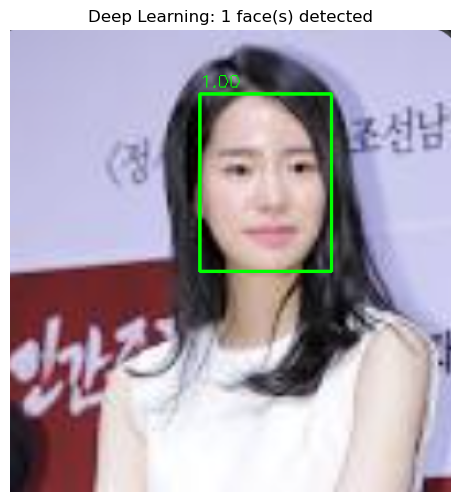

Detected 1 face(s)


In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

net = cv2.dnn.readNetFromCaffe("deploy.prototxt", "res10_300x300_ssd_iter_140000.caffemodel")

image_dnn = cv2.imread("Gambar Aktris.png")
h, w = image_dnn.shape[:2]

blob = cv2.dnn.blobFromImage(
    cv2.resize(image_dnn, (300, 300)), 1.0,
    (300, 300), (104.0, 177.0, 123.0)
)

net.setInput(blob)
detections = net.forward()

face_count = 0
for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]
    if confidence > 0.5:
        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(image_dnn, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image_dnn, f"{confidence:.2f}", (x1, y1 - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
        face_count += 1

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(image_dnn, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'Deep Learning: {face_count} face(s) detected')
plt.show()
print(f"Detected {face_count} face(s)")

In [20]:
import torch
import torchvision.models as models
import torch.nn as nn

# Load a lightweight MobileNetV2 — optimised for edge devices
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 2)  # binary: face / no face
model.eval()

# Export to ONNX format
dummy_input = torch.randn(1, 3, 224, 224)
torch.onnx.export(
    model,
    dummy_input,
    "face_detector.onnx",
    export_params=True,
    opset_version=11,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}}
)
print("Model exported to face_detector.onnx")
print(f"File size: {__import__('os').path.getsize('face_detector.onnx') / 1024 / 1024:.1f} MB")

C:\Users\User\AppData\Local\Temp\ipykernel_16264\1799591024.py:12: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0414 23:39:40.943000 16264 site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `MobileNetV2([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV2([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Users\User\anaconda3\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).


[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "C:\Users\User\anaconda3\Lib\site-packages\onnxscript\version_converter\__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "C:\Users\User\anaconda3\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "C:\Users\User\anaconda3\Lib\site-packages\onnxscript\version_converter\__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        proto, target_version=self.target_version
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\User\anaconda3\Lib\site-packages\onnx\version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(mo

[torch.onnx] Optimize the ONNX graph...
Applied 105 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅
Model exported to face_detector.onnx
File size: 0.2 MB


In [21]:
import onnxruntime as ort
import numpy as np
import cv2

# Load ONNX model — this is how it runs on a MediaTek edge device
session = ort.InferenceSession("face_detector.onnx")

# Preprocess image for inference
img = cv2.imread("Gambar Aktris.png")
img_resized = cv2.resize(img, (224, 224))
img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
img_normalized = img_rgb.astype(np.float32) / 255.0
img_transposed = np.transpose(img_normalized, (2, 0, 1))
img_input = np.expand_dims(img_transposed, axis=0)

# Run inference
input_name = session.get_inputs()[0].name
output = session.run(None, {input_name: img_input})

print("ONNX Runtime inference complete")
print(f"Output shape: {output[0].shape}")
print(f"Inference provider: {session.get_providers()}")
print("\nModel is ready for edge deployment on MediaTek-powered devices")

ONNX Runtime inference complete
Output shape: (1, 2)
Inference provider: ['CPUExecutionProvider']

Model is ready for edge deployment on MediaTek-powered devices


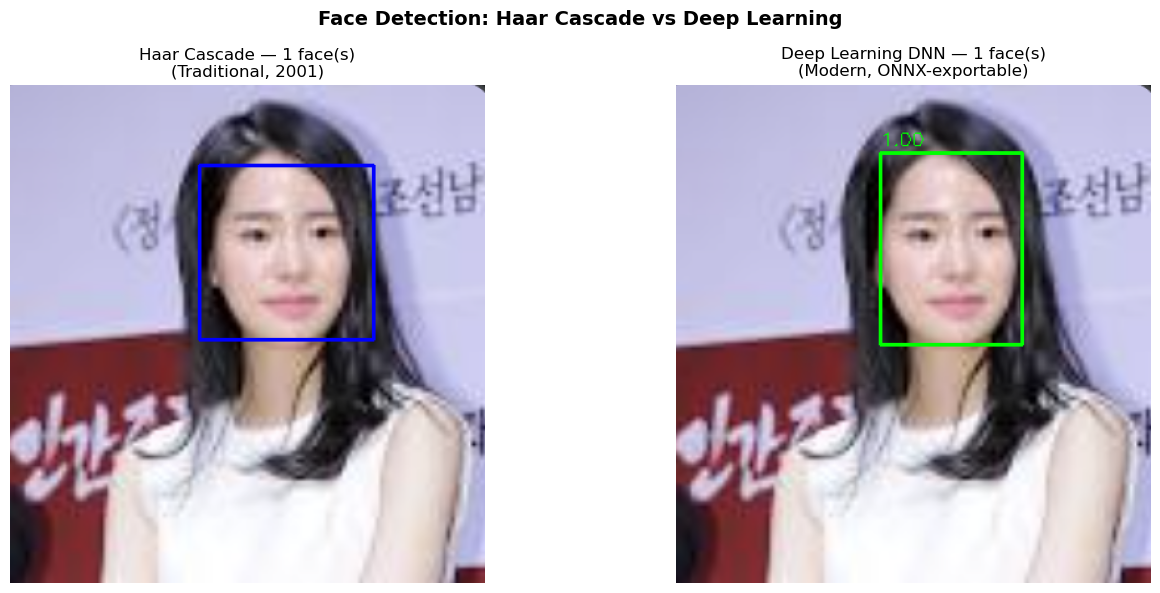

In [22]:
import matplotlib.pyplot as plt
import cv2

# Reload original image for Haar
image_haar = cv2.imread("Gambar Aktris.png")
gray = cv2.cvtColor(image_haar, cv2.COLOR_BGR2GRAY)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
faces_haar = face_cascade.detectMultiScale(gray, scaleFactor=1.05, minNeighbors=4, minSize=(50,50))
for (x, y, w, h) in faces_haar:
    cv2.rectangle(image_haar, (x, y), (x+w, y+h), (255, 0, 0), 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Face Detection: Haar Cascade vs Deep Learning', fontsize=14, fontweight='bold')

axes[0].imshow(cv2.cvtColor(image_haar, cv2.COLOR_BGR2RGB))
axes[0].axis('off')
axes[0].set_title(f'Haar Cascade — {len(faces_haar)} face(s)\n(Traditional, 2001)')

axes[1].imshow(cv2.cvtColor(image_dnn, cv2.COLOR_BGR2RGB))
axes[1].axis('off')
axes[1].set_title(f'Deep Learning DNN — {face_count} face(s)\n(Modern, ONNX-exportable)')

plt.tight_layout()
plt.show()